Citations: Andrew Lucas: Ising formulations of many NP Problems. arXiv:1302.5843. 
https://arxiv.org/abs/1302.5843

Ising machine: Hamiltonian PAth Problem

The hamiltonian path problem asks given an undirected or directed graph, can one
starting at a node travel along an edge visiting each node in the graph such
that they never return to a previously visited node. This problem is
NP-complete.

Let's improve on this in the future by creating toggle between path and cycle
variants in cycle solution notebook. 


In [1]:
import numpy as np
import scienceplots
import matplotlib.pyplot as plt
import numba
import networkx as nx
from helpers.helpers import generate_adjacency_matrix_undirected, init_random_spins

In [2]:
# ---- Hamiltonian Penalty Terms ----

# Ha: Each vertex is visited exactly once
# spins[t][v] = 1 if vertex v is visited at time t, else 0
def get_ha(A, spins):
    """Calculate the Ha term of the Hamiltonian."""
    N = spins.shape[1]  # Number of vertices
    T = spins.shape[0]  # Number of time steps

    if N != T:
        raise ValueError("Number of vertices must equal number of time steps for Ha term.")
    
    ha = 0
    for v in range(N):
        col_sum = sum(spins[t][v] for t in range(T))
        ha += A * (1 - col_sum) ** 2
    return ha

# Energy change for flipping spins[t][v] in Ha term
def get_delta_ha(A, spins, t, v):
    delta = 1 if spins[t][v] == 1 else -1
    col_sum = sum(spins[step][v] for step in range(spins.shape[0]))
    old_col_sum = col_sum - delta
    
    new_energy = A * (1 - col_sum) ** 2
    old_energy = A * (1 - old_col_sum) ** 2
    
    return new_energy - old_energy

# Hb: Each time step has exactly one vertex visited
# you cannot visit 2 vertices simulataneously
def get_hb(A, spins):
    """Calculate the Hb term of the Hamiltonian."""
    N = spins.shape[1]  # Number of vertices
    T = spins.shape[0]  # Number of time steps

    if N != T:
        raise ValueError("Number of vertices must equal number of time steps for Hb term.")
    
    hb = 0
    for t in range(T):
        row_sum = sum(spins[t][v] for v in range(N))
        hb += A * (1 - row_sum) ** 2
    return hb

def get_delta_hb(A, spins, t, v):
    """Energy change for flipping spins[t][v] in Hb term.
    Assumes flip has already been applied to spins."""
    delta = 1 if spins[t][v] == 1 else -1
    row_sum = sum(spins[t][u] for u in range(spins.shape[1]))
    old_row_sum = row_sum - delta

    new_energy = A * (1 - row_sum) ** 2
    old_energy = A * (1 - old_row_sum) ** 2

    return new_energy - old_energy

# Hc: Each visited vertex must be adjacent to the previously visited vertex.
# Don't check connection for the first and last time steps since we don't care
# about the start and end vertices in path variant
def get_hc(A, spins, adjacency_matrix):
    N = spins.shape[1]
    T = spins.shape[0]

    hc = 0
    for t in range(T - 1):  # <-- changed from range(T)
        t_next = t + 1       # <-- no more wrap-around
        for u in range(N):
            for v in range(N):
                if adjacency_matrix[u][v] == 0 and u != v:
                    hc += A * spins[t][u] * spins[t_next][v]
    return hc

def get_delta_hc(A, spins, adjacency_matrix, t, v):
    N = spins.shape[1]
    T = spins.shape[0]
    delta = 1 if spins[t][v] == 1 else -1

    cost = 0

    # boundary between t-1 and t (only if t > 0)
    if t > 0:
        for u in range(N):
            if adjacency_matrix[u][v] == 0 and u != v:
                cost += spins[t - 1][u]

    # boundary between t and t+1 (only if t < T-1)
    if t < T - 1:
        for w in range(N):
            if adjacency_matrix[v][w] == 0 and v != w:
                cost += spins[t + 1][w]

    return A * delta * cost

In [3]:
def get_full_ham(spins, adjacency_matrix, A):
    """Calculate the Hamiltonian of the system."""
    return get_ha(A, spins) + get_hb(A, spins) + get_hc(A, spins, adjacency_matrix)

In [4]:
def get_delta_hamiltonian(A, spins, adjacency_matrix, t, v):
    """Calculate the total energy change for flipping spins[t][v]."""
    delta_ha = get_delta_ha(A, spins, t, v)
    delta_hb = get_delta_hb(A, spins, t, v)
    delta_hc = get_delta_hc(A, spins, adjacency_matrix, t, v)
    return delta_ha + delta_hb + delta_hc

In [5]:
def annealing(initial_spins, adjacency_matrix, A, num_steps, T_start):
    """Perform simulated annealing to find a low-energy configuration."""
    spins = initial_spins.copy()
    energy = get_full_ham(spins, adjacency_matrix, A)

    for step in range(num_steps):
        # Randomly select a spin to flip
        t = np.random.randint(spins.shape[0])
        v = np.random.randint(spins.shape[1])

        # Flip the spin
        spins[t][v] = 1 - spins[t][v]

        dE = get_delta_hamiltonian(A, spins, adjacency_matrix, t, v)
        # Accept the flip with probability min(1, exp(-dE / T))
        T = T_start / (1 + step * 0.001) 
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            energy += dE
        else:
            # Revert the flip
            spins[t][v] = 1 - spins[t][v]

    return spins, energy


In [6]:
def plot_hamiltonian_cycle(adjacency_matrix, spins=None):
    N = adjacency_matrix.shape[0]
    G = nx.from_numpy_array(adjacency_matrix)
    pos = nx.circular_layout(G)

    plt.figure(figsize=(6, 6))

    # draw all edges in purple
    nx.draw_networkx_edges(G, pos, edge_color="purple", width=3)

    # draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=12)

    # if we have a solution, draw the cycle on top
    if spins is not None:
        T = spins.shape[0]
        cycle_edges = []
        valid = True

        for t in range(T - 1):
            t_next = (t + 1) 

            active_t = np.where(spins[t] == 1)[0]
            active_next = np.where(spins[t_next] == 1)[0]

            if len(active_t) == 0 or len(active_next) == 0:
                print(f"Invalid solution: no vertex at t={t} or t={t_next}")
                valid = False
                break

            cycle_edges.append((active_t[0], active_next[0]))

        if valid:
            nx.draw_networkx_edges(G, pos, edgelist=cycle_edges,
                                   edge_color='red', width=1, arrows=True,
                                   arrowstyle='->', arrowsize=20)

            time_labels = {}
            for t in range(T):
                active = np.where(spins[t] == 1)[0]
                if len(active) > 0:
                    time_labels[active[0]] = f"t={t}"

            label_pos = {k: (v[0], v[1] + 0.1) for k, v in pos.items()}
            nx.draw_networkx_labels(G, label_pos, time_labels,
                                    font_size=9, font_color='red')

    plt.title("Hamiltonian Path" if spins is not None else "Graph")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Retrying...
Initial Spins:
[[0 1 0 1 0 1 0 1 0 0]
 [1 0 0 1 1 0 0 1 0 1]
 [0 0 0 1 1 0 0 1 1 0]
 [0 0 0 0 0 1 0 1 0 0]
 [1 1 0 1 1 1 0 1 0 0]
 [0 1 0 0 1 0 1 0 0 0]
 [0 1 0 0 0 0 1 1 0 1]
 [0 0 0 0 1 1 1 1 1 0]
 [0 0 1 0 0 1 0 0 0 1]
 [0 0 1 0 1 0 1 0 1 1]]
Final Spins:
[[0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]]
Final Energy: 0


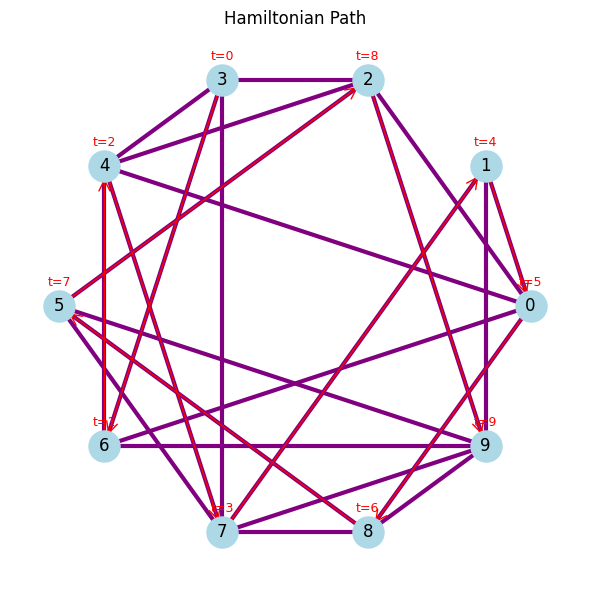

In [7]:
N = 10
adj_p = 0.5
A = 1
# initialize spin variable matrix N×N, where entry x[t][v] = 1 means "vertex v
# is at position t in the cycle - it is visited at time t"
decision_var_matrix = init_random_spins(N, 2)


# generate random undirected graph with N vertices and edge probability adj_p
adjacency_matrix = generate_adjacency_matrix_undirected(N, adj_p)


spins, energy = annealing(decision_var_matrix, adjacency_matrix, A, num_steps=1000000, T_start=10)

# redo them until the final energy is 0, meaning we found a valid Hamiltonian
# cycle. This is not guaranteed to terminate in reasonable time for large N, but
# should work for small N and moderate adj_p.
while energy != 0:
    print("Retrying...")
    decision_var_matrix = init_random_spins(N, 2)
    print("Initial Spins:")
    print(decision_var_matrix)
    spins, energy = annealing(decision_var_matrix, adjacency_matrix, A, num_steps=1000000, T_start=10)
    print("Final Spins:")
    print(spins)
    print("Final Energy:", energy)
    plot_hamiltonian_cycle(adjacency_matrix, spins)

